In [1]:
import torch
from neural_lam.weather_dataset import WeatherDataset

# if you change the seed, make sure that the randomly-applied transforms
# properly show that the image can be both transformed and *not* transformed!
torch.manual_seed(0)
standardize = True

dataset = WeatherDataset(
            "meps_example",
            pred_length=1,
            split="train",
            subsample_step=3,
            subset=bool(0),
            control_only=0,
            standardize=standardize,
            border_condition=True
        )

sample_idx = 0 # torch.randint(len(dataset), size=(1,)).item()
init_states, target_states, forcing, boundary_forcing = dataset[sample_idx]

print(f"init_states shape: {init_states.shape}")
print(f"target_states shape: {target_states.shape}")
print(f"forcing shape: {forcing.shape}")
print(f"boundary_forcing shape: {boundary_forcing.shape}")

/proj/berzelius-2022-164/users/x_erila/neural-lam/neural_lam/utils.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(
/proj/berzelius-2022-164/users/x_e

Loading sample from /proj/berzelius-2022-164/weather/neural_lam_datasets/meps_example/samples/train/nwp_2022040100_mbr000.npy
Sample name: 2022040100_mbr000
index: 0
init_states shape: torch.Size([2, 54064, 17])
target_states shape: torch.Size([1, 54064, 17])
forcing shape: torch.Size([1, 54064, 16])
boundary_forcing shape: torch.Size([1, 9720, 67])


In [2]:
len(dataset)

4

In [3]:
from neural_lam import utils, config

static_data_dict = utils.load_static_data("meps_example")
data_config = config.Config.from_file("neural_lam/data_config.yaml")

# for key, value in static_data_dict.items():
#     print(f"{key}: {value}")

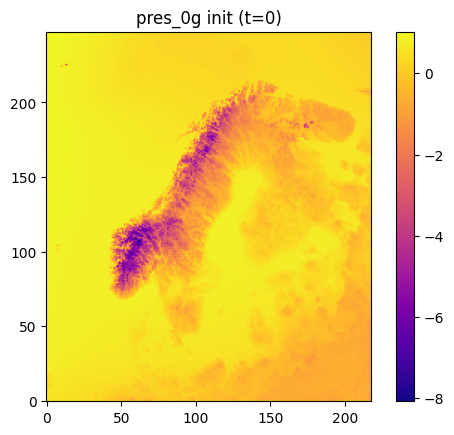

In [19]:
import matplotlib.pyplot as plt
import os
GRID_SHAPE = (248, 218)  # (y, x) without border
FULL_GRID_SHAPE = (268, 238)
VAR_IDX = 0

time_idx = 0  # choose which timestep to plot
output_dir = "./state_debug_OG"
if standardize:
    output_dir += "_standardized"
os.makedirs(output_dir, exist_ok=True)
for var_idx, var_name in enumerate(data_config.dataset.var_names):
    # init_states assumed shape (T, N, V) -> reshape to (T, Y, X, V)
    # arranged = init_states.reshape(init_states.shape[0], GRID_SHAPE[0], GRID_SHAPE[1], -1)
    if var_idx == VAR_IDX:
        arranged = target_states.reshape(target_states.shape[0], GRID_SHAPE[0], GRID_SHAPE[1], -1)

        img = arranged[time_idx, ..., var_idx]
        torch.save(img, os.path.join(output_dir, f"MEPS_OG_{var_name}_init_t{time_idx}.pt"))
        img = img.cpu().numpy() if hasattr(img, "cpu") else img.numpy()

        plt.figure()
        plt.imshow(img, cmap="plasma", origin="lower")
        plt.title(f"{var_name} init (t={time_idx})")
        plt.colorbar()
        plt.savefig(os.path.join(output_dir, f"MEPS_OG_{var_name}_init_t{time_idx}.png"))

# Assimilation

In [36]:
class Args:
    def __init__(self, **kwargs):
        for k, v in kwargs.items():
            setattr(self, k, v)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

args = Args(
            device=device
            )

In [38]:
args.obs_sigma=3.0,
args.obs_p=0.25,
args.ensemble_size=5,

args.num_ess_samples = 1
args.max_subiter = 100
args.num_ess_warmup = 100

args.pretrained_model_path = "/proj/berzelius-2022-164/users/x_erila/neural-lam/saved_models/CRPS_AR2_1200e-CRPS-6x128-09_25_10-4226/last_epoch-v199.ckpt"

In [ ]:
from neural_lam.models.crps import CRPS

# Get prior
model = CRPS(args).to(args.device)
model.load_state_dict(torch.load(args.pretrained_model_path,map_location=args.device)["state_dict"])
model.eval()
# Scale and normalize init_states
init_states_scaled = init_states


print("init_states_scaled.shape (should be [n_ens, window, state_dim, H, W]):", init_states_scaled.shape)

init_z = torch.randn(
            init_states_scaled.shape[0], model.model.noise_dim, device=args.device)

with torch.no_grad():
    prior = model.predict_step(
                        init_states_scaled, forcing, boundary_forcing, init_z)


AttributeError: 'Args' object has no attribute 'data_config'

In [16]:
truth = target_states# [0]
truth.shape

torch.Size([1, 54064, 17])

In [39]:
# Set observation mask
obs_mask = torch.rand_like(truth) < torch.tensor(args.obs_p) # Randomly mask some observations
print(f"obs_mask.shape: {obs_mask.shape}")
# obs_mask = block_obs_mask

print(f'Number of observations: {obs_mask.sum().item()}')

obs_mask.shape: torch.Size([1, 54064, 17])
Number of observations: 229238


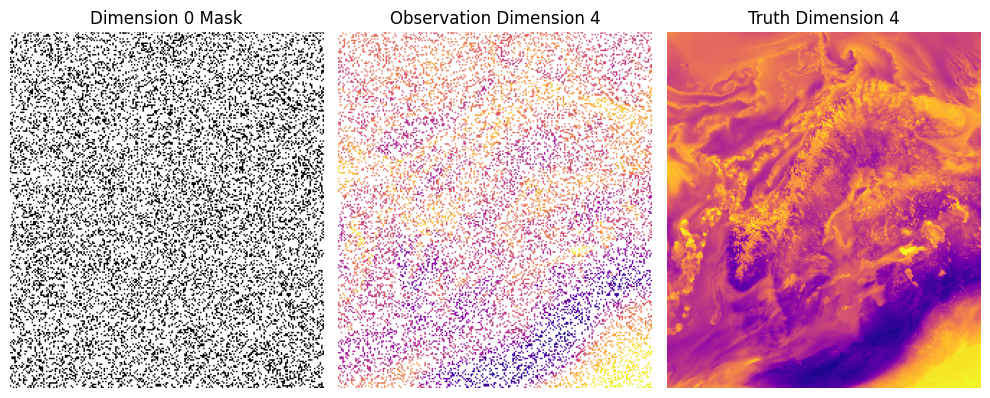

In [40]:
import matplotlib.pyplot as plt
import numpy as np
DIM=4
TIMESTEP=0

# Visualize the observation mask
fig, axs = plt.subplots(1, 3, figsize=(10, 5))

# Plot the masks
im1 = axs[0].imshow(
    obs_mask.reshape(target_states.shape[0], GRID_SHAPE[0], GRID_SHAPE[1], -1)[0, ..., 0]
    .cpu()
    .numpy()
    .astype(np.float32),
    cmap="binary",
    origin="lower",
)
axs[0].set_title("Dimension 0 Mask")

# Second dimension - overlay mask
masked_data1 = (
    truth.reshape(target_states.shape[0], GRID_SHAPE[0], GRID_SHAPE[1], -1)[TIMESTEP, ..., DIM]
    .cpu()
    .numpy()
    .astype(np.float32)
)
# alpha must be float array (0..1) or scalar; convert boolean/int to float32
mask_viz1 = (
    obs_mask.reshape(target_states.shape[0], GRID_SHAPE[0], GRID_SHAPE[1], -1)[0, ..., 0]
    .cpu()
    .numpy()
    .astype(np.float32)
)

# Show the field and overlay mask as a semi-transparent layer
axs[1].imshow(masked_data1, cmap="plasma", origin="lower", alpha=mask_viz1*1.0)
axs[1].set_title(f"Observation Dimension {DIM}")

axs[2].imshow(masked_data1, cmap="plasma", origin="lower")
axs[2].set_title(f"Truth Dimension {DIM}")

for ax in axs:
    ax.set_aspect("equal")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [51]:
# Main settings for the assimilation
observation_fn =  lambda x: x

obs = observation_fn(truth[:,obs_mask[0,:,0],:])
obs_noise = torch.randn_like(obs) * torch.tensor(args.obs_sigma) #, device=args.device)
obs = obs + obs_noise

obs_plot = obs

In [ ]:
from neural_lam.models.ess import ESS

assimilation_model = ESS(args)

posterior, log_like_list = assimilation_model.assimilate(prior, init_states, forcing, boundary_forcing, obs, obs_mask, observation_fn, debug=True)

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(log_like_list)
plt.xlabel('Logging Interval')
plt.ylabel('Average Log-Likelihood')
plt.title('Log-Likelihood Progression During ESS Assimilation')
plt.grid()
plt.show()

In [ ]:
truth.shape, prior.shape, posterior.shape

NameError: name 'prior' is not defined

In [ ]:
truth = truth.reshape(truth.shape[0], GRID_SHAPE[0], GRID_SHAPE[1], truth.shape[-1])
prior_plot = prior.reshape(prior.shape[0], -1, GRID_SHAPE[0], GRID_SHAPE[1], prior.shape[-1])
posterior_plot = posterior.reshape(posterior.shape[0], -1, GRID_SHAPE[0], GRID_SHAPE[1], posterior.shape[-1])

In [ ]:
truth.shape, prior.shape, posterior.shape

In [ ]:
TIMESTEP = -1  # choose which timestep to plot
VAR_IDX = 0  # choose which variable to plot
plot_residual=False
plot_name='test'

# Plot results
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, axs = plt.subplots(3,5, figsize=(15,10))
cmap  = 'jet'#'jet'#sns.color_palette("icefire", as_cmap=True)
#cmap  = sns.color_palette("icefire", as_cmap=True)

gds = torch.linspace(0.0, 1.0, 6, device=device)
indices = torch.linspace(0.0, 1.0, 6, device=device)

ens_mean = posterior.mean(dim=0)

if prior is None:
    prior_plot = torch.zeros_like(posterior)
    prior_alpha = torch.zeros_like(obs_mask)
else:
    prior_plot = prior[TIMESTEP, ...,VAR_IDX]
    prior_alpha = torch.ones_like(obs_mask)

if plot_residual:
    plot_prior = prior_plot - truth
    plot_posterior = posterior - truth
    plot_ens_mean = ens_mean - truth[0]

    vmin = plot_posterior[TIMESTEP, ...,VAR_IDX].min()
    vmax = plot_posterior[TIMESTEP, ...,VAR_IDX].max()
    
    vmin_prior = prior_plot[TIMESTEP, ...,VAR_IDX].min()
    vmax_prior = prior_plot[TIMESTEP, ...,VAR_IDX].max()
else:

    plot_prior = prior_plot
    plot_posterior = posterior.cpu()

    plot_ens_mean = plot_posterior.mean(dim=0)

    vmin = truth[TIMESTEP, ...,VAR_IDX].min()
    vmax = truth[TIMESTEP, ...,VAR_IDX].max()
    vmin_prior = vmin
    vmax_prior = vmax

rmse = ((1*(torch.tensor(plot_posterior.to(device)) - torch.tensor(truth.to(device)).unsqueeze(1))).pow(2).mean(dim=(0,2,3,4)).sqrt())
rmse_prior = ((1*(torch.tensor(prior, device=device) - torch.tensor(truth, device=device).unsqueeze(1))).pow(2).mean(dim=(0,2,3,4)).sqrt())
rmse_mean = ((1*(plot_posterior.to(device).mean(dim=0) - truth.to(device))).pow(2).mean(dim=(1,2,3)).sqrt())[0]
rmse_prior_mean = ((1*(prior_plot.mean(dim=0) - truth.to(device))).pow(2).mean(dim=(1,2,3)).sqrt())[0]
rmse_obs = ((1*(torch.tensor(obs_plot).to(device) - torch.tensor(truth.to(device)).unsqueeze(1))).pow(2).mean(dim=(0,2,3,4)).sqrt())

def set_cbar(im):
    ax = im.axes
    # Create an inset axes for the colorbar above the plot
    cax = inset_axes(ax,
                        width="100%",   # relative to ax width
                        height="5%",   # relative to ax height
                        loc='upper center',
                        bbox_to_anchor=(0, 0.15, 1, 1),  # place above
                        bbox_transform=ax.transAxes,
                        borderpad=0)
    cbar = plt.colorbar(im, cax=cax, orientation='horizontal')
    cbar.ax.xaxis.set_ticks_position('top')
    cbar.ax.xaxis.set_label_position('top')

# Define highlight_cell function
def highlight_cell(obs_mask, ax=None, **kwargs):
    ax = ax or plt.gca()
    for i in range(obs_mask.shape[0]):      # rows
        for j in range(obs_mask.shape[1]):  # columns
            if obs_mask[i, j]:
                rect = plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False, **kwargs)
                ax.add_patch(rect)

for i, ax in enumerate(axs.flat):
    ax.set_aspect('equal')
    if i == 0:
        im = ax.imshow(truth[0, VAR_IDX].cpu().detach().numpy(), cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title('Truth', fontsize=12)
        set_cbar(im)
    elif i ==1:
        im = ax.imshow(obs_plot[0, VAR_IDX].cpu().detach().numpy(), cmap=cmap, vmin=vmin, vmax=vmax, alpha=(obs_mask[0,VAR_IDX].cpu().detach().numpy()*1.))
        set_cbar(im)
        ax.set_title(f'Obs Recon RMSE {rmse_obs[0]:.2f}', fontsize=12)
    elif i ==2:
        ax.imshow((plot_ens_mean[VAR_IDX]).cpu().detach().numpy(), cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f'Mean {rmse_mean:.2f}', fontsize=12)
    elif i ==3:
        im = ax.imshow((prior_plot.mean(dim=0)[VAR_IDX]).cpu().detach().numpy(), cmap=cmap, vmin=vmin, vmax=vmax)
        set_cbar(im)
        ax.set_title(f'Prior mean {rmse_prior_mean:.2f}', fontsize=12)
    elif i ==4:
        im = ax.imshow((plot_posterior).std(dim=0)[VAR_IDX].cpu().detach().numpy(), cmap=cmap, vmin=0)
        ax.set_title('Std', fontsize=12)
        set_cbar(im)
    elif i < 10:
        ax.imshow((((plot_posterior)[i-5, VAR_IDX])).cpu().detach().numpy(), cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f'Posterior RMSE {rmse[i-5].item():.2f}', fontsize=12)
    else:
        ax.imshow(((prior[int(indices[i-10]*(prior.shape[0]-1)), VAR_IDX])).cpu().detach().numpy(), cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f'Prior RMSE {rmse_prior[i-10].item():.2f}', fontsize=12)
    
    ax.yaxis.set_visible(False)
    ax.xaxis.set_visible(False)
plt.tight_layout()
if plot_name != 'test':
    plt.savefig(f'{plot_name}.png')